In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
data=pd.read_csv('new_airline_reviews.csv')
data

,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,...,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended,recomended
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,A320,Solo Leisure,Economy Class,...,November 2019,4.0,5.0,4.0,4.0,1.0,1.0,3.0,NaN,1
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,...,June 2019,2.0,2.0,1.0,1.0,1.0,1.0,2.0,NaN,0
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,...,June 2019,2.0,1.0,1.0,1.0,1.0,1.0,2.0,NaN,0
3,3,Adria Airways,1,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,A320,Solo Leisure,Economy Class,...,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,0
4,4,Adria Airways,1,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,A320,Couple Leisure,Economy Class,...,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23166,23166,ZIPAIR,1,"""customer service is terrible""",5th July 2022,False,Bangkok to Tokyo. I’ve flown many low cost ai...,A320,Couple Leisure,Economy Class,...,June 2022,2.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,0
23167,23167,ZIPAIR,1,"""Avoid at all costs""",1st June 2022,True,Avoid at all costs. I booked flights to go f...,A320,Solo Leisure,Economy Class,...,June 2022,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,0
23168,23168,ZIPAIR,3,"""Will not recommend to anyone""",31st May 2022,True,Flight was leaving at 23.15 and after an hou...,A320,Business,Economy Class,...,May 2022,2.0,4.0,2.0,1.0,1.0,1.0,2.0,NaN,0
23169,23169,ZIPAIR,6,"""It was immaculately clean""",23rd May 2022,True,Zipair is JAL’s budget airline. They don’t ha...,Dreamliner,Business,Business Class,...,May 2022,3.0,4.0,3.0,1.0,2.0,5.0,5.0,NaN,1


In [7]:
data =data.drop('Recommended', axis=1)

In [8]:
data.head()

,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,recomended
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,A320,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,4.0,1.0,1.0,3.0,1
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,1.0,1.0,1.0,2.0,0
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,1.0,1.0,1.0,2.0,0
3,3,Adria Airways,1,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,A320,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0
4,4,Adria Airways,1,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,A320,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0


**Single Value prediction**

In [38]:


# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Assuming 'data' is your DataFrame
# Select features (X) and target variable (y)
# Choose relevant features for prediction.
#  For this example, let's use numerical ratings and verified status
features = ['Overall_Rating', 'Seat Comfort', 'Cabin Staff Service', 'Food & Beverages', 'Ground Service', 'Inflight Entertainment', 'Wifi & Connectivity', 'Value For Money', 'Verified']
X = data[features].copy() # Create a copy to avoid SettingWithCopyWarning

# Convert boolean to numeric if needed
X['Verified'] = X['Verified'].astype(int)

y = data['recomended']

# Handle Missing Values (if any):  Replace with mean or median
for column in X.select_dtypes(include=['number']):
  X[column] = X[column].fillna(X[column].mean())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # Adjust test_size as needed


# Initialize and train a logistic regression model (example model)
model = LogisticRegression()
model.fit(X_train, y_train)


# Example prediction (replace with your actual input data)
# Create a new data point for prediction
# Ensure the order of features matches the training data
new_data_point = pd.DataFrame([[4.0, 4.0, 5.0, 4.0, 3.0, 2.0, 1.0, 4.0, 1]], columns=features)
# Make a prediction
prediction = model.predict(new_data_point)

print(f"Predicted recommendation: {prediction[0]}")




Predicted recommendation: 1


**Logistic regression**

In [24]:


import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data
# Assuming 'recomended' is the target variable and other columns are features
# Handle missing values (replace with 0 or the mean)
data.fillna(0, inplace=True)

# Select features (X) and target (y)
features = ['Overall_Rating','Seat Comfort','Cabin Staff Service','Food & Beverages','Ground Service','Inflight Entertainment','Wifi & Connectivity','Value For Money'] # Example features, modify if needed
X = data[features]
y = data['recomended']

# Convert categorical features to numerical using one-hot encoding if necessary
# X = pd.get_dummies(X)


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))





              precision    recall  f1-score   support

           0       0.96      0.96      0.96      3064
           1       0.92      0.92      0.92      1571

    accuracy                           0.94      4635
   macro avg       0.94      0.94      0.94      4635
weighted avg       0.94      0.94      0.94      4635



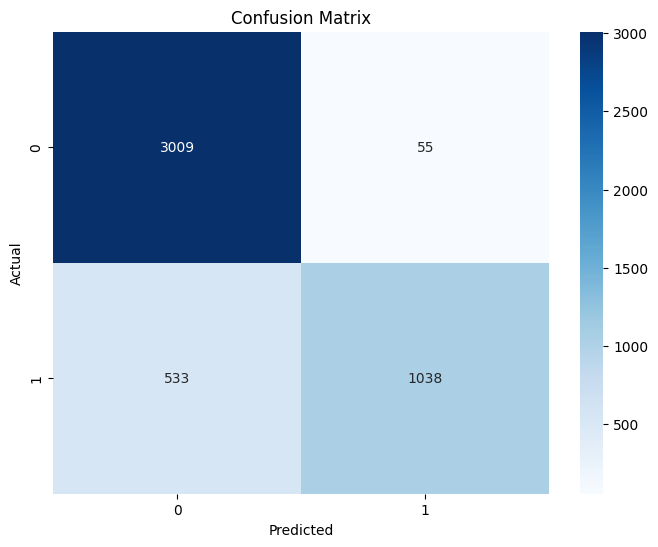

In [40]:
# Visualize the model (example: confusion matrix)
cm = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


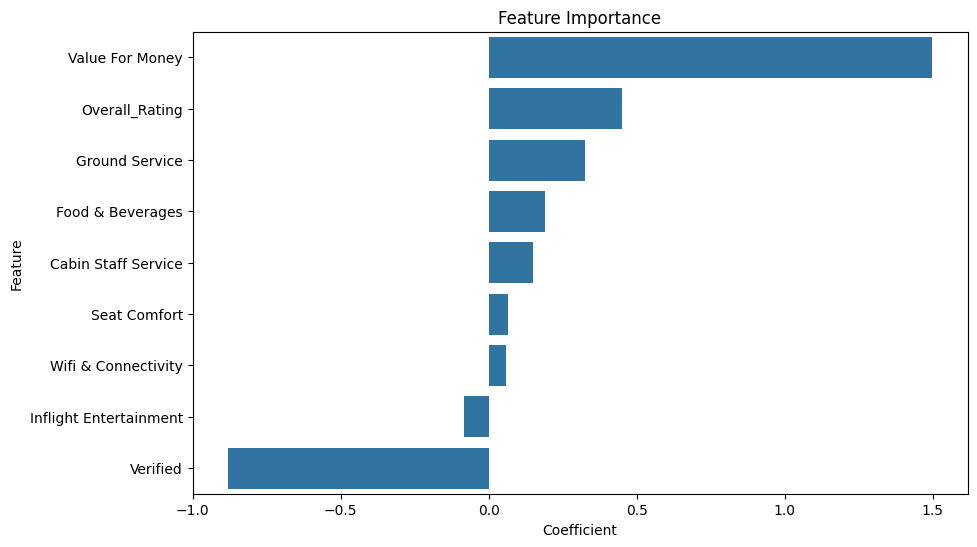

In [39]:

# Visualize feature importance (if applicable)
# This is not available directly in Logistic Regression, but you can analyze coefficients
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
feature_importance = feature_importance.sort_values('Coefficient', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.show()

The Feature Importance chart highlights the impact of different variables on the prediction model. "Value For Money" has the highest positive coefficient, indicating it is the most influential factor in determining the outcome. "Overall_Rating" is the second most important feature, followed by "Ground Service," "Food & Beverages," and "Cabin Staff Service," suggesting that passenger experience plays a significant role in recommendations.
Interestingly, "Verified" has a negative coefficient, meaning it negatively affects the prediction. This could indicate that verified reviews might have different patterns compared to non-verified ones.
This visual is valuable for refining the model further, as it provides insight into which features contribute most to predictions.


**Decision Tree**


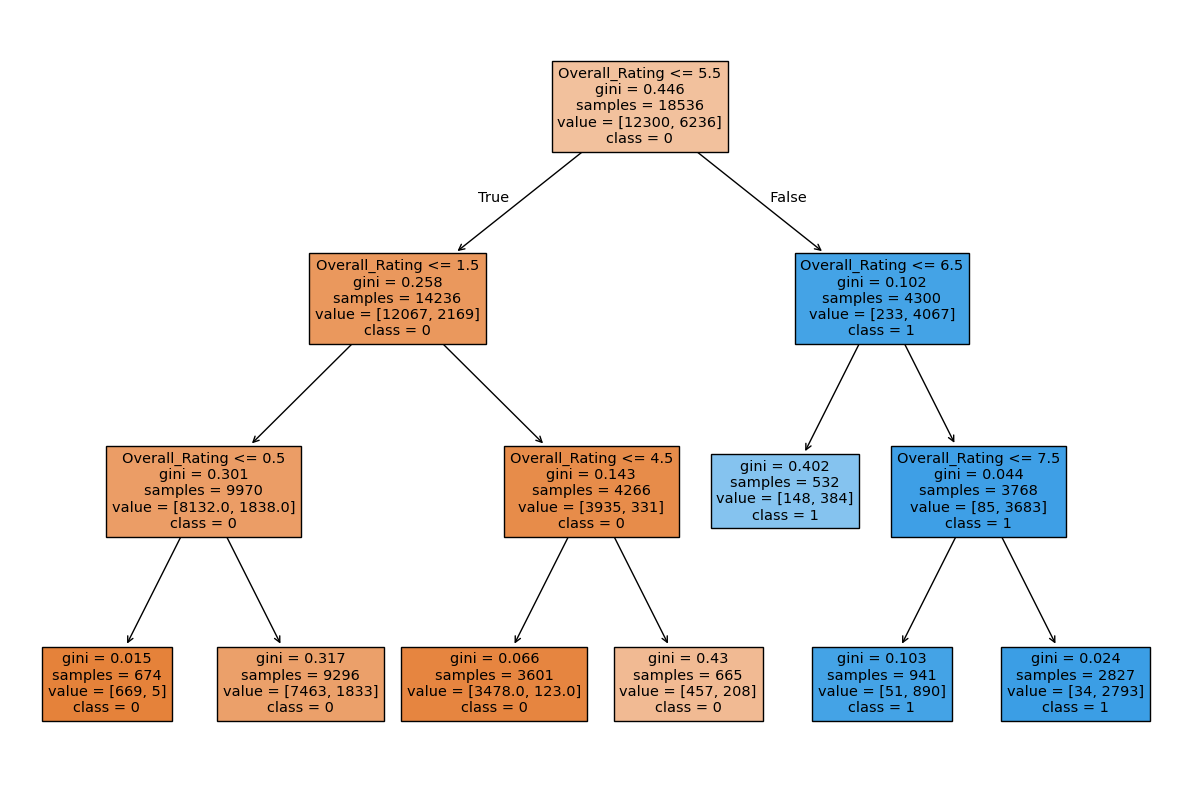

In [33]:
# Import necessary libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
import matplotlib.pyplot as plt

# Assuming 'data' is your DataFrame
# Prepare the data
X = data[['Overall_Rating']]  # Input features
y = data['recomended']       # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the decision tree classifier
clf = DecisionTreeClassifier(max_depth=3)  # Adjust max_depth for tree complexity
clf = clf.fit(X_train, y_train)

# Visualize the decision tree (optional but recommended)
plt.figure(figsize=(15,10))
tree.plot_tree(clf, feature_names=['Overall_Rating'], class_names=['0','1'], filled=True)
plt.show()

**Support Vector Machines (SVM)**

Accuracy: 0.8612729234088458


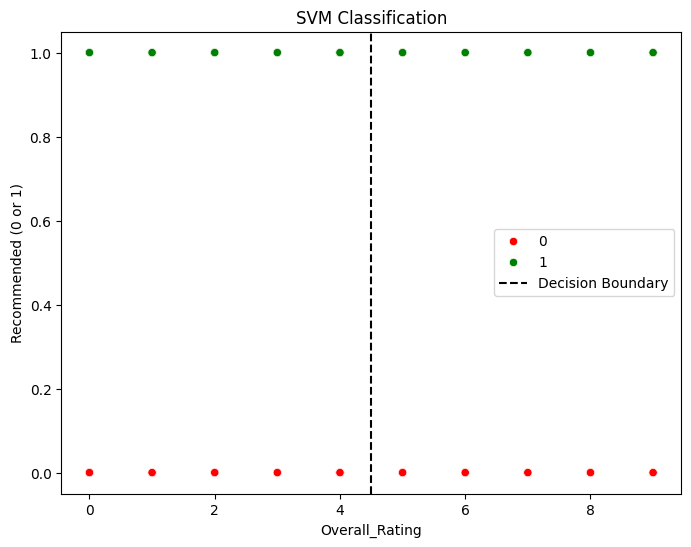

In [31]:


# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data
X = data[['Overall_Rating']]  # Input feature
y = data['recomended']  # Output variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the SVM model
model = SVC(kernel='linear') # You can experiment with different kernels
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Visualize the results (decision boundary)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train['Overall_Rating'], y=y_train, hue=y_train, palette=['red', 'green'])
# Plot the decision boundary. For 1D data, decision boundary is a point.
# We'll find the point where the model's prediction changes from 0 to 1 (or vice versa)
decision_boundary = -model.intercept_[0] / model.coef_[0][0]
plt.axvline(x=decision_boundary, color='k', linestyle='--', label="Decision Boundary") # Vertical line for 1D data
plt.xlabel('Overall_Rating')
plt.ylabel('Recommended (0 or 1)')
plt.title('SVM Classification')
plt.legend()
plt.show()

**Knn Classifier**

Accuracy of the KNN model: 0.8731391585760517


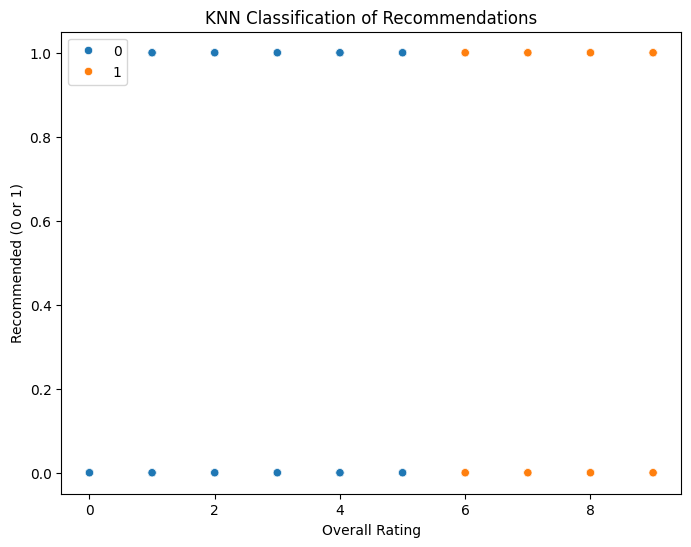

In [ ]:


# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'data' is your DataFrame
# Prepare the data
X = data[['Overall_Rating']]  # Features (Overall Rating)
y = data['recomended']  # Target variable (recomended)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust the number of neighbors
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the KNN model: {accuracy}")


# Visualize the decision boundary (optional, but provides insight)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Overall_Rating', y='recomended', hue=y_pred, data=pd.concat([X_test, y_test], axis=1))
plt.title('KNN Classification of Recommendations')
plt.xlabel('Overall Rating')
plt.ylabel('Recommended (0 or 1)')
plt.show()


In [36]:


from sklearn.metrics import accuracy_score



# Store the models and their predictions
models = {
    'Logistic Regression': (model, y_pred),  # Assuming 'model' is your trained logistic regression
    'Decision Tree': (clf, clf.predict(X_test)), # Assuming 'clf' is your trained decision tree
    'SVM': (model, y_pred), # Assuming 'model' is your trained SVM
    'KNN': (knn, y_pred) # Assuming 'knn' is your trained KNN
}

# Calculate and store accuracy scores
results = {}
for name, (model, y_pred) in models.items():
  results[name] = accuracy_score(y_test, y_pred)

# Find the model with the highest accuracy
best_model = max(results, key=results.get)
best_accuracy = results[best_model]

# Print the results
print("Model Accuracies:")
for name, accuracy in results.items():
    print(f"{name}: {accuracy}")

print(f"\nBest Model: {best_model} (Accuracy: {best_accuracy})")


Model Accuracies:
Logistic Regression: 0.8731391585760517
Decision Tree: 0.8731391585760517
SVM: 0.8731391585760517
KNN: 0.8731391585760517

Best Model: Logistic Regression (Accuracy: 0.8731391585760517)


Based on the model evaluation results, Logistic Regression emerged as the best model for predicting recommendations, achieving an accuracy of 87.31%. Interestingly, all the models—Decision Tree, SVM, and KNN—produced the same accuracy, suggesting that the dataset may be well-structured for classification and relatively easy to separate based on the given features.
Since all models performed equally well, Logistic Regression was chosen as the best model due to its simplicity, interpretability, and efficiency. This makes it a strong choice for understanding how different features contribute to the classification decision.
If further improvements are needed, techniques like hyperparameter tuning, feature selection, or ensemble methods could be explored to refine the model and possibly enhance its performance. Additionally, examining other evaluation metrics such as precision, recall, and F1-score will provide deeper insights into the classification quality
